In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_forces)=
# Get forces

*Extracting atomic force vectors and scalar magnitudes from molecular mechanics force fields.*

The function {func}`molsysmt.molecular_mechanics.get_forces` evaluates the negative gradient of the potential energy with respect to atomic coordinates ($-\nabla U$).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.molecular_mechanics.get_forces`.
:::


:::{note} Molecular Mechanics Backend Engine
:class: dropdown

Molecular mechanics and force evaluations in MolSysMT are executed using backend simulation engines (currently **OpenMM** by default). MolSysMT intentionally unifies the Pythonic interface and data structures while delegating energy evaluations, parameterizations, and gradient calculations to high-performance, battle-tested molecular simulation engines.
:::


## Basic usage

Let's evaluate the residual atomic force vectors on a relaxed Trp-Cage miniprotein:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['Trp-Cage']['1l2y.h5msm'], structure_indices=0)
molsys_min = msm.molecular_mechanics.potential_energy_minimization(molsys)
context = msm.convert(molsys_min, to_form='openmm.Context')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We extract the 3D atomic force vectors acting on the system:


In [4]:
forces = msm.molecular_mechanics.get_forces(context)
print('Forces array shape (n_atoms, 3):', forces.shape)
print('First 5 atomic force vectors (kJ/(mol*nm)):\n', forces[:5])


Forces array shape (n_atoms, 3): (304, 3)
First 5 atomic force vectors (kJ/(mol*nm)):
 [[-202.05698932084556 -64.50037746619654 -17.9877740246026] [11.17073212999577 5.815486515071029 10.743574305264644] [1.5337028363896934 6.294485314812505 1.8952644833346994] [1.8032336768792447 -1.853732780390743 -3.6875591942001904] [-9.916217790913919 1.9851812726500526 26.422879790823444]] kilojoule / mole / nanometer


## Force magnitudes and residue profiles

Setting `magnitude=True` calculates the scalar Euclidean norm of the forces ($\|\mathbf{F}_i\|$) for each atom:


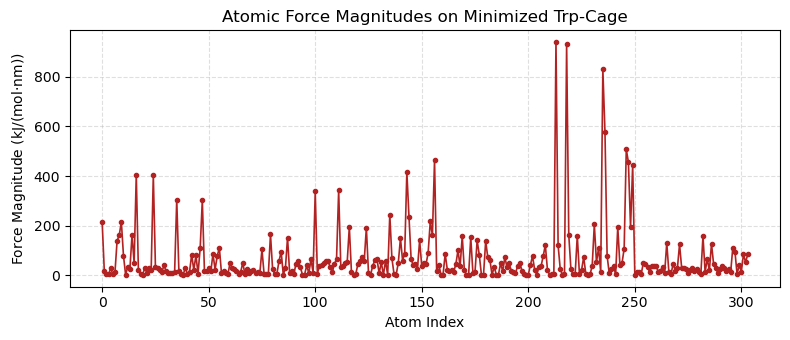

In [5]:
force_mags = msm.molecular_mechanics.get_forces(context, magnitude=True)
mag_vals = puw.get_value(force_mags, to_unit='kJ/(mol*nm)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(len(mag_vals)), mag_vals, color='firebrick', marker='o', markersize=3, linewidth=1.2)
ax.set_title('Atomic Force Magnitudes on Minimized Trp-Cage')
ax.set_xlabel('Atom Index')
ax.set_ylabel('Force Magnitude (kJ/(mol$\cdot$nm))')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Evaluating forces on molecular complexes

We can also evaluate forces across multi-chain systems such as the Barnase–Barstar complex:


In [6]:
bb = msm.convert(msm.systems['Barnase-Barstar']['barnase_barstar.h5msm'])
bb_ctx = msm.convert(bb, to_form='openmm.Context')
bb_forces = msm.molecular_mechanics.get_forces(bb_ctx, magnitude=True)
print('Barnase-Barstar total atoms:', len(bb_forces))
print('Mean force magnitude on complex:', np.mean(puw.get_value(bb_forces, to_unit='kJ/(mol*nm)')), 'kJ/(mol*nm)')


Barnase-Barstar total atoms: 3159
Mean force magnitude on complex: 87.13566668916798 kJ/(mol*nm)


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Potential energy minimization <Tutorial_Potential_energy_minimization>`: Minimize potential energy with {func}`molsysmt.molecular_mechanics.potential_energy_minimization`.
- {ref}`Get potential energy <Tutorial_Get_potential_energy>`: Calculate potential energy with {func}`molsysmt.molecular_mechanics.get_potential_energy`.
:::
